In [1]:

import os
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [5]:
# пути к данным - у меня они ничего не скоратили в плане памяти, но пусть будут - так визуально проще ориентироваться оп папка

from pathlib import Path

BASE_DIR = Path("/Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2")

DATA_DIR = BASE_DIR / "data"
DATA_LABELS = DATA_DIR / "labels"
DATA_MACRO = DATA_DIR / "macro"
DATA_PROCESSED = DATA_DIR / "processed"
DATA_RAW = DATA_DIR / "raw"


DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("BASE_DIR      :", BASE_DIR)
print("DATA_LABELS   :", DATA_LABELS)
print("DATA_MACRO    :", DATA_MACRO)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("DATA_RAW      :", DATA_RAW)


BASE_DIR      : /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2
DATA_LABELS   : /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/labels
DATA_MACRO    : /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/macro
DATA_PROCESSED: /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed
DATA_RAW      : /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/raw


In [3]:
def read_csv_safe(path, **kwargs):

    df = pd.read_csv(path, **kwargs)
    print(f"Loaded {path} -> {df.shape[0]} rows, {df.shape[1]} cols")
    return df


In [7]:
# макра и все данные для нее - ключ ставка инфляция обменный курс (взяла основные) как для модели Mundell–Fleming (IS–LM–BP)

key_rate_path = DATA_LABELS / "key_rate_history.csv"
inflation_path = DATA_MACRO / "inflation_keyrate.csv"
usd_rub_path = DATA_MACRO / "usd_rub_daily.csv"

key_rate_df   = read_csv_safe(key_rate_path)
inflation_df  = read_csv_safe(inflation_path)
usd_rub_df    = read_csv_safe(usd_rub_path)


key_rate_df["date"] = pd.to_datetime(key_rate_df["date"])
inflation_df["date"] = pd.to_datetime(inflation_df["date"])
usd_rub_df["date"] = pd.to_datetime(usd_rub_df["date"])



Loaded /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/labels/key_rate_history.csv -> 3048 rows, 2 cols
Loaded /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/macro/inflation_keyrate.csv -> 6 rows, 4 cols
Loaded /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/macro/usd_rub_daily.csv -> 3005 rows, 2 cols


In [8]:
# тексты пресс релизов

press_clean_path = DATA_PROCESSED / "cbr_press_clean.csv"
press_df = read_csv_safe(press_clean_path)

press_df.head()


Loaded /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed/cbr_press_clean.csv -> 170 rows, 4 cols


,press_date,title,url,text_clean
0,2021-10-22,Заявление Председателя Банка России Эльвиры На...,https://www.cbr.ru/press/event/?id=12361,директоров Банка России 22 октября 2021 года |...
1,2024-12-20,Заявление Председателя Банка России Эльвиры На...,https://www.cbr.ru/press/event/?id=23249,директоров Банка России 20 декабря 2024 года |...
2,2014-03-14,О ключевой ставке Банка России,https://www.cbr.ru/press/PR/?file=14032014_133...,"России 107016, Москва, ул. Неглинная, д. 12, к..."
3,2016-01-29,Банк России сохранил ключевую ставку на уровне...,https://www.cbr.ru/press/PR/?file=29012016_133...,"Банк России 107016, Москва, ул. Неглинная, д. ..."
4,2023-06-09,Заявление Председателя Банка России Эльвиры На...,https://www.cbr.ru/press/event/?id=15826,директоров Банка России 9 июня 2023 года | Бан...


In [53]:
# json to CSV (data/raw/cbr_press to csv press releases
import os
import json
import csv

folder_path = "/Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/raw/cbr_press"


output_csv = os.path.join(folder_path, "press_releases.csv")

fields = ["date", "title", "text", "url"]

rows = []

for filename in os.listdir(folder_path):
    if filename.endswith(".json"):
        file_path = os.path.join(folder_path, filename)
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)


                row = {key: data.get(key, "") for key in fields}
                rows.append(row)

        except json.JSONDecodeError:
            print(f" Ошибка чтения JSON: {filename}")
        except Exception as e:
            print(f" Ошибка в файле {filename}: {e}")


with open(output_csv, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fields)
    writer.writeheader()
    writer.writerows(rows)

print(f" Готово! Создан файл: {output_csv}")
print(f"Всего собрано записей: {len(rows)}")

 Готово! Создан файл: /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/raw/cbr_press/press_releases.csv
Всего собрано записей: 306


In [62]:
#preprocess_texts (same as preprocess_texts.py)
import nltk
nltk.download('punkt_tab')
#nltk.download('punkt')
#nltk.download('stopwords')


import pandas as pd
import numpy as np
import re
import string
from typing import List, Dict

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

import pymorphy3
from gensim.models.phrases import Phrases, Phraser

from itertools import chain
from collections import Counter


ru_stop = set(stopwords.words('russian'))
morph = pymorphy3.MorphAnalyzer()
punct = set(string.punctuation)
punct_add = ['«', '»', '“', '„', '—']

data = pd.read_csv('/Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/raw/cbr_press/press_releases.csv')


def clean(text): # spaces, переносы и регистр

    if not isinstance(text, str):
        return ""
    text = text.replace('\n', ' ').replace('\xa0', ' ').strip().lower()
    return text


def sentence(text):
    #список стр по предложениям
    sentences = sent_tokenize(text, language='russian')
    return sentences


def stopword(sentences):
    # слова в тексте, знаки препинания, числа токенизация по словам

    filtered_text = []
    stop_words = set(stopwords.words('russian'))
    for i in sentences:
        for w in word_tokenize(i, language='russian'):
            w = w.replace('–', '-').replace('—', '-')
            w = w.strip()
            if not w:
                continue
            if w in punct or w in punct_add:  # delete знаки пунктуации
                continue
            if re.fullmatch(r'\d+([.,]\d+)?', w):  # del числовые токены
                continue
            if re.fullmatch(r'\d{1,2}:\d{2}(:\d{2})?', w):  #  delete время
                continue
            if re.fullmatch(r'\d{1,2}\.\d{1,2}\.\d{2,4}', w):  # delete даты
                continue
            if re.fullmatch(r'\d{4}-\d{4}', w):  #   del год-год
                continue
            if re.fullmatch(r'\d+(?:[.\-\/]\d+)+', w):  #  del число с разделителями
                continue
            if re.fullmatch(r'\d+(?:[.,]\d+)?\s*-\s*\d+(?:[.,]\d+)?', w):  # delete числовые значения с тире
                continue
            if w in ru_stop:  # del стоп-слова
                continue
            filtered_text.append(w)
    return filtered_text


def abb(tokens):
    #abriviations/ short
    abbreviation = {
        'б.п.': 'базисный пункт',
        'б.п': 'базисный пункт',
        'рф': 'российская федерация',
        'млн': 'миллион',
        'млрд': 'миллиард',
        'г': 'год',
        'г.': 'год',
        'офз': 'облигации федерального займа'
    }
    result = []
    for w in tokens:
        key = w
        if key in abbreviation:
            result.extend(abbreviation[key].split())
        else:
            key2 = w.replace('.', '')
            if key2 in abbreviation:
                result.extend(abbreviation[key2].split())
            else:
                result.append(w)
    return result


def lemma(tokens):
    # initial form of the word / lemma listing
    lemma_list = [morph.parse(word)[0].normal_form for word in tokens]

    return lemma_list


def split_sentences_ru(text: str):
    return re.split(r'(?<=[\.\!\?])\s+|\n+', text) if isinstance(text, str) else []


INC_RE = re.compile(
    r'(?:(?<!не\s)(повыс\w+|повышени\w+|увелич\w+).{0,30}(ключев\w*\s+ставк\w*))|'
    r'(?:(ключев\w*\s+ставк\w*).{0,30}(?<!не\s)(повыс\w+|повышени\w+|увелич\w+))',
    re.IGNORECASE
)
DEC_RE = re.compile(
    r'(?:(?<!не\s)(сниз\w+|пониз\w+|снижени\w+|уменьш\w+).{0,30}(ключев\w*\s+ставк\w*))|'
    r'(?:(ключев\w*\s+ставк\w*).{0,30}(?<!не\s)(сниз\w+|пониз\w+|снижени\w+|уменьш\w+))',
    re.IGNORECASE
)
FLAT_RE = re.compile(
    r'(?:(без\s+измен\w+|не\s+измен\w+|на\s+уровне|сохран\w+|остав\w+\s+(?:без\s+измен\w+)?).{0,30}(ключев\w*\s+ставк\w*))|'
    r'(?:(ключев\w*\s+ставк\w*).{0,30}(без\s+измен\w+|не\s+измен\w+|на\s+уровне|сохран\w+|остав\w+\s+(?:без\s+измен\w+)?))',
    re.IGNORECASE
)


def decision_key_rate(text, as_string=False):
    # Функция выделяем решени по ключевой ставке: +1 / -1 / 0 / nan

    if not isinstance(text, str) or not text.strip():
        return np.nan

    t = text.lower()
    if INC_RE.search(t):
        return '+1' if as_string else 1
    elif DEC_RE.search(t):
        return '-1' if as_string else -1
    elif FLAT_RE.search(t):
        return '0' if as_string else 0
    else:
        return np.nan


def key_rate(text):
    # Функция возвращает размер ключевой ставки key rate size number.,nember%

    if not isinstance(text, str) or not text.strip():
        return None
    t = text.lower()
    pct = r'(\d{1,2}(?:[.,]\d{1,2})?)\s*(?:%|процент\w*)'
    dash = r'[–—-]'

    candidates = []
    for s in split_sentences_ru(t):
        if 'ключев' not in s or 'ставк' not in s:
            continue
        for m in re.finditer(pct, s, flags=re.IGNORECASE):
            val = float(m.group(1).replace(',', '.'))
            left = s[max(0, m.start() - 6):m.start()]
            right = s[m.end(): m.end() + 6]
            if re.search(fr'\d\s*{dash}\s*$', left) or re.search(fr'^{dash}\s*\d', right):
                continue
            window = s[max(0, m.start() - 30): m.end() + 30]
            score = 0
            if re.search(r'\b(до|на\s+уровне|состав(ит|лял[аи]|ляет)|установ(лен[ао]?|ить))\b', window):
                score += 2
            candidates.append((score, val))

    if not candidates:
        return None
    candidates.sort(key=lambda x: (x[0], - (10 <= x[1] <= 25)), reverse=True)
    return round(candidates[0][1], 2)


def get_ngrams(tokens, n=2):
    if not isinstance(tokens, list) or len(tokens) < n:
        return []
    if n == 2:
        return list(zip(tokens, tokens[1:]))
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def process_series(text_sr: pd.Series, title_sr: pd.Series = None):
    # dict
    if title_sr is not None:
        raw = (title_sr.fillna('') + ' ' + text_sr.fillna('')).str.strip()
    else:
        raw = text_sr.fillna('')

    cleaned = text_sr.fillna("").map(clean)  # убираем NaN значения и применяем функция очиски текста
    sents = cleaned.map(sentence)  # применяем функцию разделения по предложениям к очищенному тексту
    tokens = sents.map(stopword).map(
        abb)  # применяем функцию очистки от стоп слов к разделенному по предложениям тексту, расшифровки аббревитарур
    lemmas = tokens.map(lemma)  # применяем функцию лемматизации к токенам с расшифроваными аббревиатурами
    bigrams = lemmas.map(lambda lst: get_ngrams(lst, 2))
    decisions = raw.map(decision_key_rate)
    rates = raw.map(key_rate)

    return {
        "clean": cleaned,
        "sentences": sents,
        "tokens": tokens,
        "lemmas": lemmas,
        "bigrams": bigrams,
        "decision": decisions,
        "key_rate": rates
    }


# прогоняем столбец "текст" через функцию process_series и возвращаем
# в новые колонки в таблице
text_add = process_series(data.text, data.title)
data['text_clean'] = text_add['clean']
data['text_sentences'] = text_add['sentences']
data['text_tokens'] = text_add['tokens']
data['text_lemmas'] = text_add['lemmas']
data['text_bigrams'] = text_add['bigrams']

# прогоняем столбец "заголовок" через функцию process_series и возвращаем
# в новые колонки в таблице
title_add = process_series(data.title)
data['title_clean'] = title_add['clean']
data['title_sentences'] = title_add['sentences']
data['title_tokens'] = title_add['tokens']
data['title_lemmas'] = title_add['lemmas']
data['title_bigrams'] = title_add['bigrams']

data['decision'] = text_add['decision']
data['key_rate'] = text_add['key_rate']

data.to_json('cbr_key-rate_press_releases_processed.json', orient='records', force_ascii=False, indent=2)

#Taceback поиск ошибок - не надо для самого проекта
data.head()
data.columns
print(data.shape)
print(data.columns)
data.head()



[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/polinakokova/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(306, 16)
Index(['date', 'title', 'text', 'url', 'text_clean', 'text_sentences', 'text_tokens', 'text_lemmas', 'text_bigrams',
       'title_clean', 'title_sentences', 'title_tokens', 'title_lemmas', 'title_bigrams', 'decision', 'key_rate'],
      dtype='object')


,date,title,text,url,text_clean,text_sentences,text_tokens,text_lemmas,text_bigrams,title_clean,title_sentences,title_tokens,title_lemmas,title_bigrams,decision,key_rate
0,2024-08-30,Банк России установил более строгие ограничени...,Банк России установил более строгие ограничени...,https://www.cbr.ru/press/pr/?file=638606197703...,банк россии установил более строгие ограничени...,[банк россии установил более строгие ограничен...,"[банк, россии, установил, строгие, ограничения...","[банк, россия, установить, строгий, ограничени...","[(банк, россия), (россия, установить), (устано...",банк россии установил более строгие ограничени...,[банк россии установил более строгие ограничен...,"[банк, россии, установил, строгие, ограничения...","[банк, россия, установить, строгий, ограничени...","[(банк, россия), (россия, установить), (устано...",NaN,NaN
1,2019-07-26,Банк России сохранил надбавки к коэффициентам ...,Банк России сохранил надбавки к коэффициентам ...,https://www.cbr.ru/press/pr/?file=26072019_175...,банк россии сохранил надбавки к коэффициентам ...,[банк россии сохранил надбавки к коэффициентам...,"[банк, россии, сохранил, надбавки, коэффициент...","[банк, россия, сохранить, надбавка, коэффициен...","[(банк, россия), (россия, сохранить), (сохрани...",банк россии сохранил надбавки к коэффициентам ...,[банк россии сохранил надбавки к коэффициентам...,"[банк, россии, сохранил, надбавки, коэффициент...","[банк, россия, сохранить, надбавка, коэффициен...","[(банк, россия), (россия, сохранить), (сохрани...",NaN,NaN
2,2025-11-27,Инфляционные ожидания в ноябре повысились,Инфляционные ожидания в ноябре повысились | Ба...,https://www.cbr.ru/press/event/?id=28134,инфляционные ожидания в ноябре повысились | ба...,[инфляционные ожидания в ноябре повысились | б...,"[инфляционные, ожидания, ноябре, повысились, б...","[инфляционный, ожидание, ноябрь, повыситься, б...","[(инфляционный, ожидание), (ожидание, ноябрь),...",инфляционные ожидания в ноябре повысились,[инфляционные ожидания в ноябре повысились],"[инфляционные, ожидания, ноябре, повысились]","[инфляционный, ожидание, ноябрь, повыситься]","[(инфляционный, ожидание), (ожидание, ноябрь),...",NaN,NaN
3,2021-10-22,Заявление Председателя Банка России Эльвиры На...,Заявление Председателя Банка России Эльвиры На...,https://www.cbr.ru/press/event/?id=12361,заявление председателя банка россии эльвиры на...,[заявление председателя банка россии эльвиры н...,"[заявление, председателя, банка, россии, эльви...","[заявление, председатель, банк, россия, эльвир...","[(заявление, председатель), (председатель, бан...",заявление председателя банка россии эльвиры на...,[заявление председателя банка россии эльвиры н...,"[заявление, председателя, банка, россии, эльви...","[заявление, председатель, банк, россия, эльвир...","[(заявление, председатель), (председатель, бан...",1.0,7.5
4,2024-12-20,Заявление Председателя Банка России Эльвиры На...,Заявление Председателя Банка России Эльвиры На...,https://www.cbr.ru/press/event/?id=23249,заявление председателя банка россии эльвиры на...,[заявление председателя банка россии эльвиры н...,"[заявление, председателя, банка, россии, эльви...","[заявление, председатель, банк, россия, эльвир...","[(заявление, председатель), (председатель, бан...",заявление председателя банка россии эльвиры на...,[заявление председателя банка россии эльвиры н...,"[заявление, председателя, банка, россии, эльви...","[заявление, председатель, банк, россия, эльвир...","[(заявление, председатель), (председатель, бан...",1.0,21.0


In [56]:
#build_labels.py
import pandas as pd

INP = DATA_LABELS / "key_rate_history.csv"
OUT = DATA_LABELS / "key_rate_history.csv"


def to_label(diff: float):
    """Переводим разницу ставки в метку -1/0/1/NaN."""
    if pd.isna(diff):
        # нет следующей даты -> отсутствует метка
        return pd.NA
    if diff == 0:
        return 0
    return 1 if diff > 0 else -1


def main():
    print(f"[build_labels] читаю историю ставок из {INP}...")
    hist = pd.read_csv(INP)

    # инфо/дата парсинг
    hist["date"] = pd.to_datetime(hist["date"])
    hist = hist.sort_values("date").reset_index(drop=True)

    # ставка на следующем заседании
    hist["rate_next"] = hist["rate"].shift(-1)

    # difference and label/ метка
    diff = hist["rate_next"] - hist["rate"]
    hist["label"] = diff.apply(to_label)

    # raws only with (label не NaN)
    out = hist.dropna(subset=["label"]).copy()

    # label --> (Int64)
    out["label"] = out["label"].astype("Int64")

    out.to_csv(OUT, index=False)
    print(f"[build_labels] OK, labels saved -> {OUT}")
    print(out[["date", "rate", "rate_next", "label"]].head(10))



if __name__ == "__main__":
    main()

[build_labels] читаю историю ставок из /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/labels/key_rate_history.csv...
[build_labels] OK, labels saved -> /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/labels/key_rate_history.csv
        date  rate  rate_next  label
0 2013-09-17   5.5        5.5      0
1 2013-09-18   5.5        5.5      0
2 2013-09-19   5.5        5.5      0
3 2013-09-20   5.5        5.5      0
4 2013-09-23   5.5        5.5      0
5 2013-09-24   5.5        5.5      0
6 2013-09-25   5.5        5.5      0
7 2013-09-26   5.5        5.5      0
8 2013-09-27   5.5        5.5      0
9 2013-09-30   5.5        5.5      0


In [57]:
#align_texts_labels.py


PRESS_CSV = DATA_PROCESSED /"cbr_press_clean.csv"
LABELS_CSV = DATA_LABELS /"key_rate_labels.csv"
OUT_CSV = DATA_PROCESSED /"dataset_labeled.csv"


def main():
    print(f"[align_texts_labels] читаю пресс-релизы из {PRESS_CSV}...")
    press = pd.read_csv(PRESS_CSV)

    # парсинг инфо даты из релизов
    press["press_date"] = pd.to_datetime(press["press_date"])

    # читаем и сочетаем метка-> заседание
    print(f"[align_texts_labels] читаю метки заседаний из {LABELS_CSV}...")
    labels = pd.read_csv(LABELS_CSV, parse_dates=["date"])
    labels = labels.sort_values("date").reset_index(drop=True)

    # сортируем пресс-релизы для merge_asof
    press = press.sort_values("press_date").reset_index(drop=True)

    # merge_asof: к каждому press_date прицепляем ближайший date >= press_date
    # direction="forward" = "следующее" дате/ часу / времени
    print("[align_texts_labels] маплю каждый пресс-релиз к ближайшему следующему заседанию...")
    merged = pd.merge_asof(
        press,
        labels,
        left_on="press_date",
        right_on="date",
        direction="forward",
    )

    # meeting_date = дата заседания (может быть NaT, если заседания нет)
    merged["meeting_date"] = merged["date"]

    # decision = label по ставке (-1/0/1 или NaN)
    merged = merged.rename(columns={"label": "decision"})

    # приводим meeting_date к строке (YYYY-MM-DD), но в CSV храним как есть (Timestamp тоже ок)
    merged["meeting_date"] = merged["meeting_date"].dt.date.astype("string")

    cols = ["press_date", "meeting_date", "decision", "title", "url", "text_clean"]
    ds = merged[cols].copy()

    ds.to_csv(OUT_CSV, index=False)
    print(f"[align_texts_labels] OK, сохранено -> {OUT_CSV}; строк: {len(ds)}")
    print(ds.head(5))


if __name__ == "__main__":
    main()

[align_texts_labels] читаю пресс-релизы из /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed/cbr_press_clean.csv...
[align_texts_labels] читаю метки заседаний из /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/labels/key_rate_labels.csv...
[align_texts_labels] маплю каждый пресс-релиз к ближайшему следующему заседанию...
[align_texts_labels] OK, сохранено -> /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed/dataset_labeled.csv; строк: 170
  press_date meeting_date  decision                                              title  \
0 2014-02-14   2014-02-14         0                     О ключевой ставке Банка России   
1 2014-02-14   2014-02-14         0  Заявление Председателя Банка России Э.С. Набиу...   
2 2014-03-03   2014-03-03         0                     О ключевой ставке Банка России   
3 2014-03-14   2014-03-14         0                     О ключевой ставке Банка России   
4

In [60]:
#analyze_texts_and_macro.py

import pandas as pd
from pandas.tseries.offsets import MonthEnd

# Пути к данным
DATASET_TIMELINE = DATA_PROCESSED / "dataset_timeline.csv"
KEYRATE_CSV = DATA_LABELS / "key_rate_history.csv"
INFL_CSV = DATA_MACRO / "inflation_keyrate.csv"
USDRUB_CSV = DATA_MACRO / "usd_rub_daily.csv"
REPORTS_DIR = "reports"

# Очень грубый набор русских стоп-слов + слова про Банк России
RUS_STOPWORDS = {
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "ее", "мне", "есть", "если", "или", "ни", "они", "такой",
    "этот", "тот", "для", "чтобы", "это", "при", "мы", "от", "о", "из",
    "что", "который", "также", "таких", "такие", "их", "же", "года", "году",
    "банка", "россии", "банк", "россия",
}


def ensure_reports_dir():
    os.makedirs(REPORTS_DIR, exist_ok=True)

def tokenize(text: str):
    text = text.lower()
    tokens = re.findall(r"[а-яёa-z]+", text)
    tokens = [t for t in tokens if t not in RUS_STOPWORDS and len(t) > 2]
    return tokens

def top_words_overall():

    print("[EDA] считаю ОБЩИЙ топ слов в пресс-релизах...")
    df = pd.read_csv(DATASET_TIMELINE)
    texts = df["text_clean"].fillna("").tolist()

    cnt = Counter()
    for t in texts:
        cnt.update(tokenize(t))

    top100 = cnt.most_common(100)
    out_path = os.path.join(REPORTS_DIR, "top_words_overall.csv")
    pd.DataFrame(top100, columns=["word", "count"]).to_csv(out_path, index=False)
    print(f"[EDA] общий top_words -> {out_path}")


def _top_words_for_subset(df_subset: pd.DataFrame):
    cnt = Counter()
    for t in df_subset["text_clean"].fillna(""):
        cnt.update(tokenize(t))
    return cnt.most_common(100)


def top_words_by_decision():
    """
    Топ слов отдельно:
      - перед повышением ставки (decision == 1)
      - перед понижением ставки (decision == -1)
      - перед сохранением ставки (decision == 0)

    Берём только релизы с is_between == True,
    то есть находящиеся МЕЖДУ двумя решениями.
    """
    print("[EDA] считаю топ слов по типу будущего решения (decision)...")
    df = pd.read_csv(DATASET_TIMELINE)

    # оставляем только строки, где известен decision
    df = df.dropna(subset=["decision"]).copy()

    # decision может быть float -> приводим к int
    df["decision"] = df["decision"].astype(int)

    # если колонки is_between нет (на всякий случай) — считаем, что все релизы учитываем
    if "is_between" in df.columns:
        base = df[df["is_between"] == True].copy()
    else:
        base = df.copy()

    # Подмножества
    hikes = base[base["decision"] == 1]    # перед повышением
    cuts = base[base["decision"] == -1]    # перед понижением
    holds = base[base["decision"] == 0]    # перед сохранением

    print(f"[EDA] релизов перед повышением: {len(hikes)}")
    print(f"[EDA] релизов перед понижением: {len(cuts)}")
    print(f"[EDA] релизов перед сохранением: {len(holds)}")

    # считаем топы
    hikes_top = _top_words_for_subset(hikes)
    cuts_top = _top_words_for_subset(cuts)
    holds_top = _top_words_for_subset(holds)

    pd.DataFrame(hikes_top, columns=["word", "count"]).to_csv(
        os.path.join(REPORTS_DIR, "top_words_before_hike.csv"), index=False
    )
    pd.DataFrame(cuts_top, columns=["word", "count"]).to_csv(
        os.path.join(REPORTS_DIR, "top_words_before_cut.csv"), index=False
    )
    pd.DataFrame(holds_top, columns=["word", "count"]).to_csv(
        os.path.join(REPORTS_DIR, "top_words_before_hold.csv"), index=False
    )

    print("[EDA] топы слов по decision сохранены в:")
    print("  - reports/top_words_before_hike.csv")
    print("  - reports/top_words_before_cut.csv")
    print("  - reports/top_words_before_hold.csv")


# макра

def build_macro():
    """
    Собираем единый датафрейм macro с колонками: дата инфляция ставка обменный курс
    """

    # История ставки
    keyrate = pd.read_csv(KEYRATE_CSV, parse_dates=["date"])
    keyrate = keyrate.sort_values("date").reset_index(drop=True)

    # Курс USD/RUB (дневной) - она по идее не сильно нужна, но тоже пусть будет
    usdrub = pd.read_csv(USDRUB_CSV, parse_dates=["date"])
    usdrub = usdrub.sort_values("date").reset_index(drop=True)

    #Инфляция + ставка помесячно
    infl = pd.read_csv(INFL_CSV)
    infl_dates_parsed = pd.to_datetime(infl["date"], errors="coerce")
    min_year = infl_dates_parsed.dt.year.min()

    # если инфляция с кривыми датами (1970 и т.п.) — подставляем последние N месяцев
    if pd.isna(min_year) or min_year < 1990:
        n = len(infl)
        last_calendar_date = keyrate["date"].max()
        last_month_end = (last_calendar_date + MonthEnd(0)).normalize()
        months = [last_month_end - MonthEnd(n - 1 - i) for i in range(n)]
        infl["date"] = pd.to_datetime(months)
        print(
            f"[EDA] инфляция: некорректные даты в CSV, "
            f"подставляю {n} последних месяцев до {last_month_end.date()}"
        )
    else:
        infl["date"] = infl_dates_parsed

    if "inflation_yoy" not in infl.columns:
        raise RuntimeError(
            f"[EDA] В {INFL_CSV} нет колонки 'inflation_yoy' — посмотри структуру файла"
        )

    # выше писала, что по дням не самое важно - это потому что теперь делаем ремеплинг по месяцам все равно
    # ключевая ставка: последнее значение в каждом месяце
    keyrate_m = (
        keyrate.set_index("date")["rate"]
        .resample("M")
        .last()
        .reset_index()
        .rename(columns={"rate": "key_rate_m"})
    )
    keyrate_m["month"] = keyrate_m["date"].dt.to_period("M")

    # курс usd/rub: средний за месяц
    usdrub_m = (
        usdrub.set_index("date")["usd_rub"]
        .resample("M")
        .mean()
        .reset_index()
        .rename(columns={"usd_rub": "usd_rub_m"})
    )
    usdrub_m["month"] = usdrub_m["date"].dt.to_period("M")

    # инфляция: месяцы → период
    infl["month"] = pd.to_datetime(infl["date"]).dt.to_period("M")

    macro = (
        infl.merge(keyrate_m[["month", "key_rate_m"]], on="month", how="left")
        .merge(usdrub_m[["month", "usd_rub_m"]], on="month", how="left")
    )

    macro["date"] = macro["month"].dt.to_timestamp("M")
    macro = macro.dropna(subset=["inflation_yoy", "key_rate_m", "usd_rub_m"])

    print("[EDA] macro preview:")
    print(macro[["date", "inflation_yoy", "key_rate_m", "usd_rub_m"]])

    return macro


def plot_macro(macro: pd.DataFrame):
    print("[EDA] строю макро-графики...")

    # Тайм-серия: ключевая ставка и инфляция
    plt.figure(figsize=(10, 5))
    plt.plot(macro["date"], macro["key_rate_m"], label="Key rate, %")
    plt.plot(macro["date"], macro["inflation_yoy"], label="Inflation, % YoY")
    plt.legend()
    plt.title("Ключевая ставка и инфляция (помесячно)")
    plt.grid(True)
    out_ts1 = os.path.join(REPORTS_DIR, "keyrate_vs_inflation_timeseries.png")
    plt.savefig(out_ts1, bbox_inches="tight")
    plt.close()
    print(f"[EDA] сохранён график {out_ts1}")

    # Тайм-серия: USD/RUB
    plt.figure(figsize=(10, 5))
    plt.plot(macro["date"], macro["usd_rub_m"])
    plt.title("USD/RUB (средний курс за месяц)")
    plt.grid(True)
    out_ts2 = os.path.join(REPORTS_DIR, "usd_rub_timeseries.png")
    plt.savefig(out_ts2, bbox_inches="tight")
    plt.close()
    print(f"[EDA] сохранён график {out_ts2}")

    # Scatter: key rate vs inflation
    plt.figure(figsize=(6, 6))
    plt.scatter(macro["key_rate_m"], macro["inflation_yoy"])
    plt.xlabel("Key rate, %")
    plt.ylabel("Inflation, % YoY")
    plt.title("Ключевая ставка vs инфляция")
    plt.grid(True)
    out_sc1 = os.path.join(REPORTS_DIR, "scatter_keyrate_inflation.png")
    plt.savefig(out_sc1, bbox_inches="tight")
    plt.close()
    print(f"[EDA] сохранён график {out_sc1}")

    # Scatter: key rate vs USD/RUB
    plt.figure(figsize=(6, 6))
    plt.scatter(macro["key_rate_m"], macro["usd_rub_m"])
    plt.xlabel("Key rate, %")
    plt.ylabel("USD/RUB")
    plt.title("Ключевая ставка vs курс USD/RUB")
    plt.grid(True)
    out_sc2 = os.path.join(REPORTS_DIR, "scatter_keyrate_usdrub.png")
    plt.savefig(out_sc2, bbox_inches="tight")
    plt.close()
    print(f"[EDA] сохранён график {out_sc2}")

    # Корреляции
    corr = macro[["key_rate_m", "inflation_yoy", "usd_rub_m"]].corr()
    out_corr = os.path.join(REPORTS_DIR, "macro_correlations.csv")
    corr.to_csv(out_corr)
    print(f"[EDA] корреляции сохранены в {out_corr}")
    print(corr)


def main():
    ensure_reports_dir()
    # Общий топ слов
    top_words_overall()
    # Топ слов по типу решения (перед повышением / понижением / сохранением)
    top_words_by_decision()
    # Макро-графики
    macro = build_macro()
    if macro.empty:
        print("[EDA] ВНИМАНИЕ: macro пустой — проверь файлы макро-данных.")
    else:
        plot_macro(macro)
    plot_word_hist_hike_vs_cut(top_n=25)

import networkx as nx

def plot_word_hist_hike_vs_cut(top_n: int = 25):

    print("[EDA] строю зеркальную гистограмму слов для hike vs cut...")

    hike_path = os.path.join(REPORTS_DIR, "top_words_before_hike.csv")
    cut_path = os.path.join(REPORTS_DIR, "top_words_before_cut.csv")

    if not (os.path.exists(hike_path) and os.path.exists(cut_path)):
        print("[EDA] Нет файлов top_words_before_hike/cut — сначала запусти top_words_by_decision().")
        return

    hike = pd.read_csv(hike_path)
    cut = pd.read_csv(cut_path)

    # Приводим к словарь: слово -> count
    hike_dict = dict(zip(hike["word"], hike["count"]))
    cut_dict = dict(zip(cut["word"], cut["count"]))

    # Общее множество слов
    all_words = set(hike_dict.keys()) | set(cut_dict.keys())

    # Для каждого слова берём максимум частоты между двумя классами
    rows = []
    for w in all_words:
        c_h = hike_dict.get(w, 0)
        c_c = cut_dict.get(w, 0)
        max_c = max(c_h, c_c)
        rows.append((w, c_h, c_c, max_c))

    df = pd.DataFrame(rows, columns=["word", "count_hike", "count_cut", "max_count"])
    # Берём топ-N слов по max_count
    df = df.sort_values("max_count", ascending=False).head(top_n)

    # Индекс по x
    x = range(len(df))
    hike_vals = df["count_hike"].tolist()
    cut_vals = df["count_cut"].tolist()

    # Рисуем зеркальную гистограмму
    plt.figure(figsize=(12, 6))

    # Верхняя гистограмма (повышение)
    plt.bar(x, hike_vals, width=0.8, label="Перед повышением (decision=1)")

    # Нижняя гистограмма (понижение) — просто отрицательные значения
    plt.bar(x, [-v for v in cut_vals], width=0.8, label="Перед понижением (decision=-1)")

    # Линия нуля
    plt.axhline(0, color="black", linewidth=1)

    # Подписи по оси X — слова
    plt.xticks(x, df["word"].tolist(), rotation=45, ha="right")

    plt.ylabel("Частота слова")
    plt.title(f"Частотность слов перед повышением и понижением ставки (топ-{top_n})")
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(REPORTS_DIR, "word_hist_hike_vs_cut.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"[EDA] зеркальная гистограмма сохранена -> {out_path}")




if __name__ == "__main__":
    main()

[EDA] считаю ОБЩИЙ топ слов в пресс-релизах...
[EDA] общий top_words -> reports/top_words_overall.csv
[EDA] считаю топ слов по типу будущего решения (decision)...
[EDA] релизов перед повышением: 16
[EDA] релизов перед понижением: 19
[EDA] релизов перед сохранением: 33
[EDA] топы слов по decision сохранены в:
  - reports/top_words_before_hike.csv
  - reports/top_words_before_cut.csv
  - reports/top_words_before_hold.csv
[EDA] инфляция: некорректные даты в CSV, подставляю 5 последних месяцев до 2025-11-30


/var/folders/n7/w07z75hd2k3f9qddzcc8g5lr0000gn/T/ipykernel_25731/2430244596.py:154: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/n7/w07z75hd2k3f9qddzcc8g5lr0000gn/T/ipykernel_25731/2430244596.py:164: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


[EDA] macro preview:
        date  inflation_yoy  key_rate_m  usd_rub_m
0 2025-07-31           9.40        18.0  78.772404
1 2025-08-31           8.79        18.0  80.127786
2 2025-09-30           8.14        17.0  82.970805
3 2025-10-31           7.98        16.5  80.921374
4 2025-11-30           7.71        16.5  80.343825
[EDA] строю макро-графики...
[EDA] сохранён график reports/keyrate_vs_inflation_timeseries.png
[EDA] сохранён график reports/usd_rub_timeseries.png
[EDA] сохранён график reports/scatter_keyrate_inflation.png
[EDA] сохранён график reports/scatter_keyrate_usdrub.png
[EDA] корреляции сохранены в reports/macro_correlations.csv
               key_rate_m  inflation_yoy  usd_rub_m
key_rate_m       1.000000       0.935394  -0.508863
inflation_yoy    0.935394       1.000000  -0.618351
usd_rub_m       -0.508863      -0.618351   1.000000
[EDA] строю зеркальную гистограмму слов для hike vs cut...
[EDA] зеркальная гистограмма сохранена -> reports/word_hist_hike_vs_cut.png


In [61]:
#text nlp insights
import pandas as pd

INP = DATA_PROCESSED / "dataset_labeled.csv"
OUT = DATA_PROCESSED / "dataset_timeline.csv"


def detect_announcements(df: pd.DataFrame) -> pd.Series:
    #заголовок содержит что-то про "ключевую ставку" или URL содержит характерные куски "/keypr/", "keyrate", "key.htm" и т.п.

    title = df["title"].fillna("").str.lower()
    url = df["url"].fillna("").str.lower()

    mask_title = (
        title.str.contains("ключев", na=False) &
        title.str.contains("ставк", na=False)
    )

    mask_url = url.str.contains(
        r"keyrate|key_rate|/keypr/|key\.htm",
        regex=True,
        na=False
    )

    return mask_title | mask_url


def main():
    print(f"[build_timeline_flags] читаю датасет из {INP}...")
    df = pd.read_csv(INP)

    df["press_date"] = pd.to_datetime(df["press_date"])

    if "meeting_date" in df.columns:
        df["meeting_date"] = pd.to_datetime(df["meeting_date"], errors="coerce")

    df = df.sort_values("press_date").reset_index(drop=True)

    print("[build_timeline_flags] определяю is_announcement по title/url...")
    df["is_announcement"] = detect_announcements(df)

    print("[build_timeline_flags] считаю prev_announcement_date / next_announcement_date...")

    ann_dates = df["press_date"].where(df["is_announcement"])

    # предыдущий анонс (ffill)
    df["prev_announcement_date"] = ann_dates.ffill()

    # следующий анонс (bfill)
    df["next_announcement_date"] = ann_dates.bfill()

    df["is_between"] = (
        (~df["is_announcement"]) &
        df["prev_announcement_date"].notna() &
        df["next_announcement_date"].notna()
    )

    # prev/next как строки формата YYYY-MM-DD
    df["prev_announcement_date"] = df["prev_announcement_date"].dt.date.astype("string")
    df["next_announcement_date"] = df["next_announcement_date"].dt.date.astype("string")

    base_cols = ["press_date", "meeting_date", "decision", "title", "url", "text_clean"]
    flag_cols = ["is_announcement", "is_between", "prev_announcement_date", "next_announcement_date"]

    cols = [c for c in base_cols + flag_cols if c in df.columns]
    df_out = df[cols].copy()

    df_out.to_csv(OUT, index=False)
    print(f"[build_timeline_flags] OK, сохранено -> {OUT}; строк: {len(df_out)}")
    print(df_out.head(5))


if __name__ == "__main__":
    main()

[build_timeline_flags] читаю датасет из /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed/dataset_labeled.csv...
[build_timeline_flags] определяю is_announcement по title/url...
[build_timeline_flags] считаю prev_announcement_date / next_announcement_date...
[build_timeline_flags] OK, сохранено -> /Users/polinakokova/Desktop/HSE/keyRateForecast/keyRateForecast-Polina 2/data/processed/dataset_timeline.csv; строк: 170
  press_date meeting_date  decision                                              title  \
0 2014-02-14   2014-02-14         0                     О ключевой ставке Банка России   
1 2014-02-14   2014-02-14         0  Заявление Председателя Банка России Э.С. Набиу...   
2 2014-03-03   2014-03-03         0                     О ключевой ставке Банка России   
3 2014-03-14   2014-03-14         0                     О ключевой ставке Банка России   
4 2014-04-25   2014-04-25         1                     О ключевой ставке Банка России   

 

In [48]:
# Импорты и базовые настройки в сотый раз, но чтобы точно ничего не терялось :))

import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

DATASET_TIMELINE = DATA_PROCESSED / "dataset_timeline.csv"
REPORTS_DIR = "reports"

RUS_STOPWORDS = {
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "ее", "мне", "есть", "если", "или", "ни", "они", "такой",
    "этот", "тот", "для", "чтобы", "это", "при", "мы", "от", "о", "из",
    "что", "который", "также", "таких", "такие", "их", "же", "года", "году",
    "банка", "россии", "банк", "россия",
}

os.makedirs(REPORTS_DIR, exist_ok=True)

def tokenize(text: str):
    text = str(text).lower()
    tokens = re.findall(r"[а-яёa-z]+", text)
    tokens = [t for t in tokens if t not in RUS_STOPWORDS and len(t) > 2]
    return tokens

def load_base_dataframe():
    df = pd.read_csv(DATASET_TIMELINE)
    df = df.dropna(subset=["decision"]).copy()
    df["decision"] = df["decision"].astype(int)
    if "is_between" in df.columns:
        df = df[df["is_between"] == True].copy()
    df["text_clean"] = df["text_clean"].fillna("")
    print(f"[NLP] загружено {len(df)} релизов с decision и is_between=True")
    return df

df = load_base_dataframe()
df.head()


[NLP] загружено 68 релизов с decision и is_between=True


,press_date,meeting_date,decision,title,url,text_clean,is_announcement,is_between,prev_announcement_date,next_announcement_date
1,2014-02-14,2014-02-14,0,Заявление Председателя Банка России Э.С. Набиу...,https://www.cbr.ru/press/event/?id=5200,директоров 14 февраля 2014 года | Банк России ...,False,True,2014-02-14,2014-03-03
5,2014-06-16,2014-06-16,0,Заявление Председателя Банка России Э.С. Набиу...,https://www.cbr.ru/press/event/?id=5204,директоров 16 июня 2014 года | Банк России 107...,False,True,2014-04-25,2014-06-16
9,2014-09-12,2014-09-12,0,Заявление Председателя Банка России Э.С. Набиу...,https://www.cbr.ru/press/event/?id=5208,директоров 12 сентября 2014 года | Банк России...,False,True,2014-09-12,2014-10-31
11,2014-12-11,2014-12-11,1,Заявление Председателя Банка России Э.С. Набиу...,https://www.cbr.ru/press/event/?id=5214,директоров 11 декабря 2014 года | Банк России ...,False,True,2014-10-31,2014-12-11
15,2015-03-13,2015-03-13,-1,Заявление Председателя Банка России Э.С. Набиу...,https://www.cbr.ru/press/event/?id=5215,директоров 13 марта 2015 года | Банк России 10...,False,True,2015-01-30,2015-03-13


[NLP] лог-odds: релизов hike=16, cut=19


,word,freq_hike,freq_cut,p_hike,p_cut,log_odds
1197,первичном,15,0,0.000195,1.204296e-07,7.388343
7332,ипотечный,13,0,0.000169,1.204296e-07,7.245345
13355,плавающей,12,0,0.000156,1.204296e-07,7.165366
2537,стандарт,12,0,0.000156,1.204296e-07,7.165366
14783,разрыва,12,0,0.000156,1.204296e-07,7.165366
4659,плавающих,12,0,0.000156,1.204296e-07,7.165366
2676,взноса,12,0,0.000156,1.204296e-07,7.165366
3051,список,11,0,0.000143,1.204296e-07,7.078430
10643,плавающие,11,0,0.000143,1.204296e-07,7.078430
11761,недвижимости,10,0,0.000130,1.204296e-07,6.983211


,word,freq_hike,freq_cut,p_hike,p_cut,log_odds
12500,нрд,0,18,1.297386e-07,0.000217,-7.421641
2899,движению,0,10,1.297386e-07,0.000121,-6.834298
12662,отсечения,0,10,1.297386e-07,0.000121,-6.834298
11991,профициту,0,10,1.297386e-07,0.000121,-6.834298
2674,аукционы,0,10,1.297386e-07,0.000121,-6.834298
1588,низкими,0,10,1.297386e-07,0.000121,-6.834298
567,отрицательных,0,10,1.297386e-07,0.000121,-6.834298
3918,заморожены,0,9,1.297386e-07,0.000109,-6.729049
12174,пенсионных,0,9,1.297386e-07,0.000109,-6.729049
8653,дома,0,9,1.297386e-07,0.000109,-6.729049


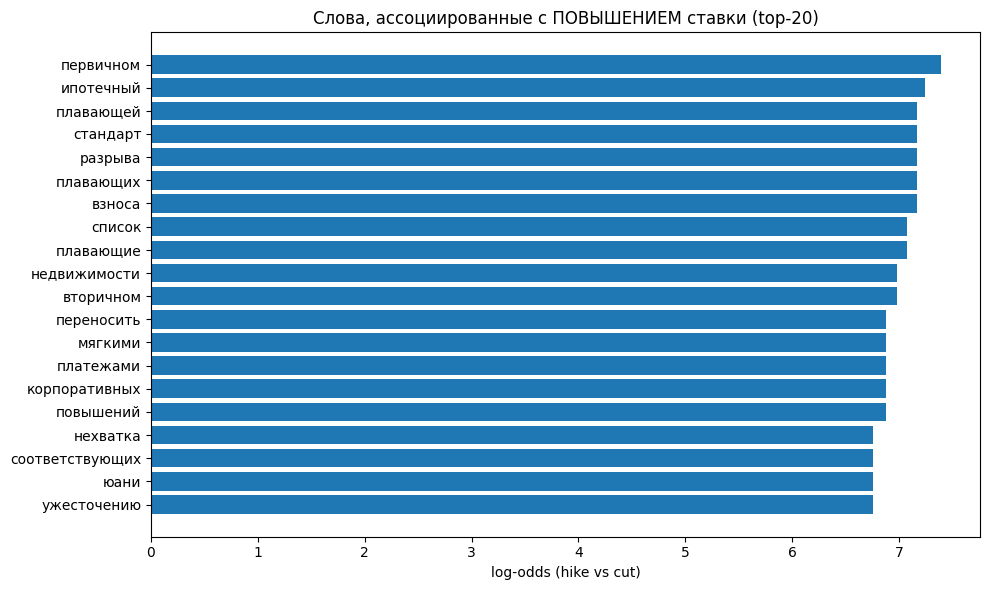

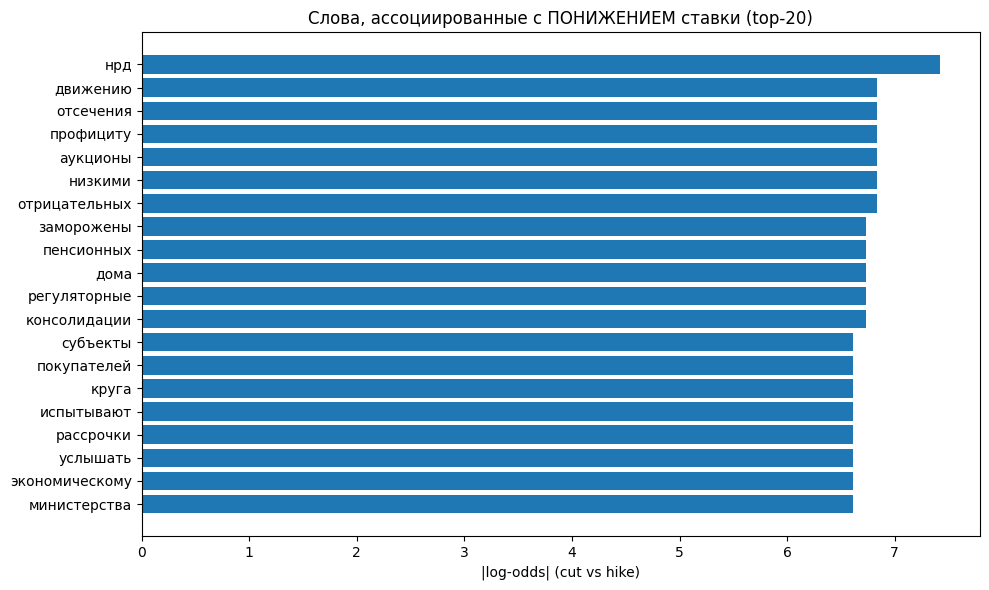

In [49]:
# Лог-odds слова для hike vs cut

def compute_log_odds_hike_vs_cut(df, alpha: float = 0.01, top_n: int = 50):
    hikes = df[df["decision"] == 1]
    cuts = df[df["decision"] == -1]

    print(f"[NLP] лог-odds: релизов hike={len(hikes)}, cut={len(cuts)}")

    cnt_h = Counter()
    cnt_c = Counter()

    for t in hikes["text_clean"]:
        cnt_h.update(tokenize(t))
    for t in cuts["text_clean"]:
        cnt_c.update(tokenize(t))

    all_words = set(cnt_h.keys()) | set(cnt_c.keys())
    V = len(all_words)
    N_h = sum(cnt_h.values())
    N_c = sum(cnt_c.values())

    rows = []
    for w in all_words:
        fh = cnt_h.get(w, 0)
        fc = cnt_c.get(w, 0)
        p_h = (fh + alpha) / (N_h + alpha * V)
        p_c = (fc + alpha) / (N_c + alpha * V)
        log_odds = np.log(p_h) - np.log(p_c)
        rows.append((w, fh, fc, p_h, p_c, log_odds))

    out = pd.DataFrame(
        rows,
        columns=["word", "freq_hike", "freq_cut", "p_hike", "p_cut", "log_odds"],
    ).sort_values("log_odds", ascending=False)

    out.to_csv(os.path.join(REPORTS_DIR, "logodds_hike_vs_cut.csv"), index=False)
    top_hike = out.head(top_n)
    top_cut = out.tail(top_n).iloc[::-1]

    top_hike.to_csv(os.path.join(REPORTS_DIR, "logodds_top_hike.csv"), index=False)
    top_cut.to_csv(os.path.join(REPORTS_DIR, "logodds_top_cut.csv"), index=False)

    return top_hike, top_cut

top_hike, top_cut = compute_log_odds_hike_vs_cut(df, alpha=0.01, top_n=50)

display(top_hike.head(20))
display(top_cut.head(20))

plt.figure(figsize=(10, 6))
th = top_hike.head(20)
y_pos = range(len(th))
plt.barh(y_pos, th["log_odds"].values)
plt.yticks(y_pos, th["word"].tolist())
plt.gca().invert_yaxis()
plt.xlabel("log-odds (hike vs cut)")
plt.title("Слова, ассоциированные с ПОВЫШЕНИЕМ ставки (top-20)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
tc = top_cut.head(20)
y_pos = range(len(tc))
plt.barh(y_pos, (-tc["log_odds"]).values)
plt.yticks(y_pos, tc["word"].tolist())
plt.gca().invert_yaxis()
plt.xlabel("|log-odds| (cut vs hike)")
plt.title("Слова, ассоциированные с ПОНИЖЕНИЕМ ставки (top-20)")
plt.tight_layout()
plt.show()


[NLP] кластеризация релизов по TF-IDF + KMeans...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


decision,-1,0,1
cluster,,,
0,0,3,6
1,3,7,5
2,5,7,2
3,5,9,3
4,4,2,0
5,0,1,0
6,2,2,0
7,0,2,0


,cluster,n_docs,top_terms
0,0,9,"пандемии, нейтральной, ипотеки, базисных, пунк..."
1,1,15,"ипотеки, заботкин, выручки, импорт, иис, льгот..."
2,2,14,"млрд, долл, сша, долларов, резервов, сценарии,..."
3,3,17,"заботкин, бюджета, ипотеки, инвесторов, проект..."
4,4,6,"смягчение, смягчения, нейтральной, ограничител..."
5,5,1,"марта, планируем, условиям, адаптации, над, то..."
6,6,4,"ликвидности, долларов, сценарии, профициту, ба..."
7,7,2,"раздел, особенности, сведения, займам, отчетно..."


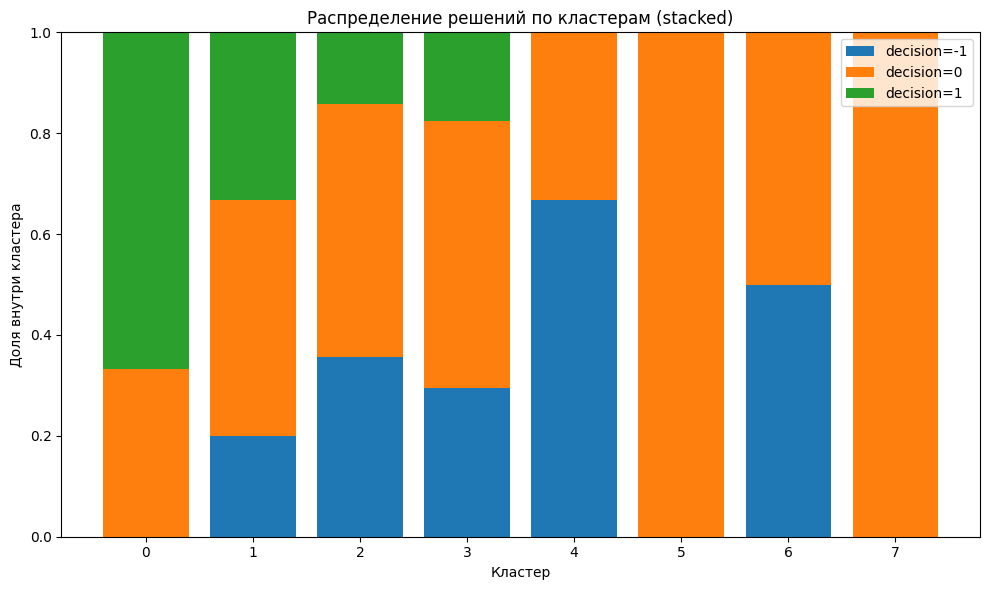

In [50]:
# Кластеризация релизов и распределение решений

def cluster_releases(df, n_clusters: int = 8, max_features: int = 5000):
    print("[NLP] кластеризация релизов по TF-IDF + KMeans...")

    texts = df["text_clean"].tolist()

    vectorizer = TfidfVectorizer(
        tokenizer=tokenize,
        max_features=max_features,
        min_df=3,
        max_df=0.7,
    )
    X = vectorizer.fit_transform(texts)

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    labels = km.fit_predict(X)

    df_clusters = df.copy()
    df_clusters["cluster"] = labels

    crosstab = pd.crosstab(df_clusters["cluster"], df_clusters["decision"])
    crosstab.to_csv(os.path.join(REPORTS_DIR, "clusters_decision_crosstab.csv"))

    terms = np.array(vectorizer.get_feature_names_out())
    cluster_rows = []
    for cl in range(n_clusters):
        center = km.cluster_centers_[cl]
        top_idx = center.argsort()[::-1][:15]
        top_terms = ", ".join(terms[top_idx])
        n_docs = (df_clusters["cluster"] == cl).sum()
        cluster_rows.append(
            {"cluster": cl, "n_docs": n_docs, "top_terms": top_terms}
        )

    clusters_overview = pd.DataFrame(cluster_rows)
    clusters_overview.to_csv(
        os.path.join(REPORTS_DIR, "clusters_overview.csv"), index=False
    )

    return df_clusters, crosstab, clusters_overview

df_clusters, crosstab, clusters_overview = cluster_releases(
    df, n_clusters=8, max_features=5000
)

display(crosstab)
display(clusters_overview)

ctab = crosstab.copy().astype(float)
ctab = ctab.div(ctab.sum(axis=1), axis=0)

clusters_idx = ctab.index.tolist()
decisions = sorted(ctab.columns.tolist())

x = np.arange(len(clusters_idx))
bottoms = np.zeros(len(clusters_idx))

plt.figure(figsize=(10, 6))
for d in decisions:
    vals = ctab[d].values
    plt.bar(x, vals, bottom=bottoms, label=f"decision={d}")
    bottoms += vals

plt.xticks(x, [str(c) for c in clusters_idx])
plt.ylabel("Доля внутри кластера")
plt.xlabel("Кластер")
plt.title("Распределение решений по кластерам (stacked)")
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# Тематическое моделирование LDA

def build_topics_lda(df, n_topics: int = 10, max_features: int = 5000):
    print("[NLP] тематическое моделирование LDA...")

    texts = df["text_clean"].tolist()

    vectorizer = CountVectorizer(
        tokenizer=tokenize,
        max_features=max_features,
        min_df=5,
        max_df=0.8,
    )
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        random_state=42,
    )
    lda.fit(X)

    terms = np.array(vectorizer.get_feature_names_out())
    topic_rows = []
    for topic_idx, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[::-1][:20]
        top_terms = ", ".join(terms[top_idx])
        topic_rows.append({"topic_id": topic_idx, "top_terms": top_terms})

    topics_df = pd.DataFrame(topic_rows)
    topics_df.to_csv(os.path.join(REPORTS_DIR, "topics_lda.csv"), index=False)
    return topics_df

topics_df = build_topics_lda(df, n_topics=10, max_features=5000)
topics_df.head(10)


[NLP] тематическое моделирование LDA...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,topic_id,top_terms
0,0,"нефть, сша, долларов, млрд, сценарии, чуть, ли..."
1,1,"ипотеки, про, труда, курс, люди, компании, заб..."
2,2,"люди, мировой, денег, прошлого, про, ипотеки, ..."
3,3,"курс, ограничения, первый, иис, бумаги, валютн..."
4,4,"труда, замедление, высокой, люди, бюджета, люд..."
5,5,"особенности, вопросы, общие, отчетность, расче..."
6,6,"валюты, ликвидности, курс, экономического, неф..."
7,7,"ипотеки, валюты, люди, про, экспорта, граждан,..."
8,8,"июня, мая, операции, проводиться, марта, новых..."
9,9,"млрд, сша, долларов, темпов, ликвидности, март..."


[NLP] считаю PMI bigrams...


,w1,w2,freq_bigram,freq_w1,freq_w2,pmi
5656,первоначальному,взносу,5,5,5,11.016410
3935,платежными,системами,5,5,5,11.016410
4455,the,bell,5,6,5,10.834089
5802,созаемщика,созаемщиков,6,6,6,10.834089
5806,занимающихся,предпринимательской,6,6,6,10.834089
5427,денежную,массу,5,5,6,10.834089
4743,красный,север,6,6,6,10.834089
4546,заработную,плату,5,5,6,10.834089
5849,документально,подтвержденной,6,6,6,10.834089
5865,примерным,перечнем,6,6,6,10.834089


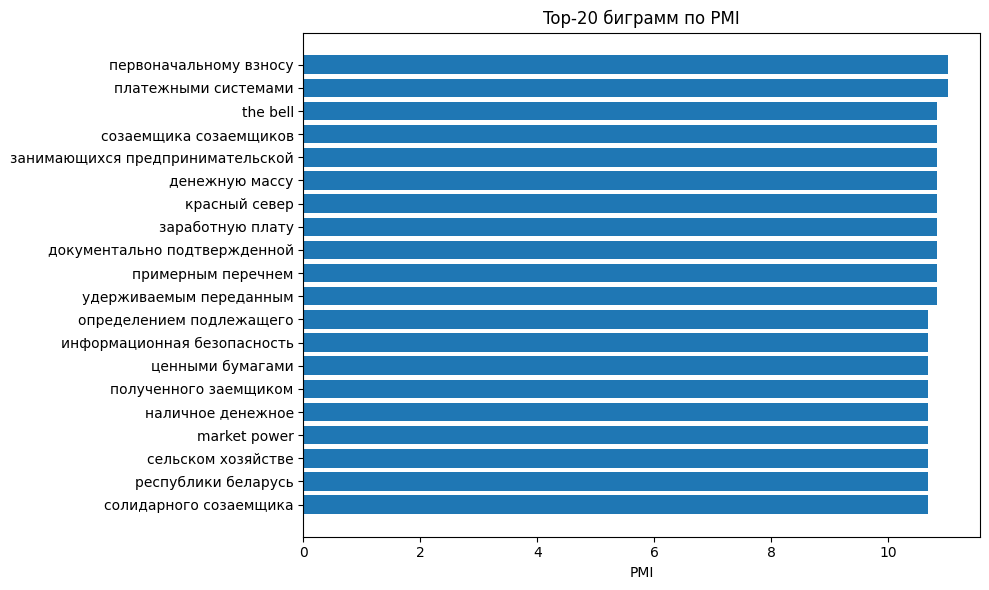

In [52]:
# PMI биграммы

def compute_pmi_bigrams(df, min_count: int = 5, top_n: int = 200):
    print("[NLP] считаю PMI bigrams...")

    tokenized_docs = [tokenize(t) for t in df["text_clean"]]
    word_counts = Counter()
    bigram_counts = Counter()

    total_tokens = 0
    for toks in tokenized_docs:
        word_counts.update(toks)
        total_tokens += len(toks)
        for i in range(len(toks) - 1):
            bigram = (toks[i], toks[i + 1])
            bigram_counts[bigram] += 1

    rows = []
    for (w1, w2), f_xy in bigram_counts.items():
        if f_xy < min_count:
            continue
        f_x = word_counts[w1]
        f_y = word_counts[w2]
        p_x = f_x / total_tokens
        p_y = f_y / total_tokens
        p_xy = f_xy / max(1, total_tokens - 1)
        pmi = np.log(p_xy / (p_x * p_y))
        rows.append((w1, w2, f_xy, f_x, f_y, pmi))

    if not rows:
        print("[NLP] мало биграмм для PMI (rows=0)")
        return pd.DataFrame()

    out = pd.DataFrame(
        rows,
        columns=["w1", "w2", "freq_bigram", "freq_w1", "freq_w2", "pmi"],
    ).sort_values("pmi", ascending=False).head(top_n)

    out.to_csv(os.path.join(REPORTS_DIR, "bigrams_pmi.csv"), index=False)
    return out

bi_df = compute_pmi_bigrams(df, min_count=5, top_n=200)
display(bi_df.head(20))

if not bi_df.empty:
    b = bi_df.head(20).copy()
    labels = [f"{w1} {w2}" for w1, w2 in zip(b["w1"], b["w2"])]
    y_pos = range(len(b))

    plt.figure(figsize=(10, 6))
    plt.barh(y_pos, b["pmi"].values)
    plt.yticks(y_pos, labels)
    plt.gca().invert_yaxis()
    plt.xlabel("PMI")
    plt.title("Top-20 биграмм по PMI")
    plt.tight_layout()
    plt.show()
